In [1]:
# Load the Dataset

import pandas as pd  # For data manipulation and analysis

df = pd.read_csv(r"C:\Users\salma\Desktop\dalya\project healthcare\kaggle supply chain datasets\my work\inventory_EDA.csv")

In [2]:
df.head()

,Date,Item_Type,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time,Shortage_Risk,Reorder_Point,Need_More_Space
0,2024-10-01,0,1542,264,1018,4467.55,108,17,1,1968.0,1
1,2024-10-02,1,2487,656,3556,5832.29,55,12,0,988.0,0
2,2024-10-03,1,2371,384,5562,16062.98,470,6,1,3012.0,0
3,2024-10-04,0,2038,438,1131,744.10,207,15,1,3324.0,1
4,2024-10-05,1,2410,338,1013,15426.53,158,12,0,2065.0,1


First model will be a shortage risk classifier.

In [42]:
# Define features and target
X = df.drop(['Shortage_Risk' , 'Date' , 'Max_Capacity' , 'Need_More_Space' , 'Avg_Usage_Per_Day' , 'Restock_Lead_Time'], axis = 1)   # Features
y = df['Shortage_Risk']  # Target variable

In [43]:
# Train-test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)


In [44]:
# Feature Scaling (for models that require it, like logistic regression or SVM)

from sklearn.preprocessing import StandardScaler

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Only transform, don't fit again!

As my target column is imbalanced and I didn't apply oversampling, I'll only use tree-based models here

Accuracy Score: 0.96
ROC AUC Score: 0.9565972222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.97      0.97      0.97        64

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



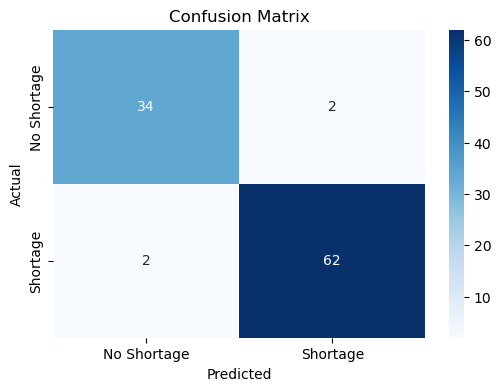

In [45]:
# random forest
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Initialize Random Forest classifier with class weight
rf_model = RandomForestClassifier(
    n_estimators=200,  # Number of trees
    max_depth=10,  # Maximum tree depth
    min_samples_split=5,  # Minimum samples required to split
    min_samples_leaf=2,  # Minimum samples at leaf
    class_weight=weights_dict,  # Handle class imbalance
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=['No Shortage', 'Shortage'], yticklabels=['No Shortage', 'Shortage'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [58]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV
grid_search = GridSearchCV(RandomForestClassifier(class_weight=weights_dict, random_state=42), param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Train best model
best_rf_model = grid_search.best_estimator_

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9877593479252166


Accuracy Score: 0.97
ROC AUC Score: 0.9704861111111112
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.98      0.97      0.98        64

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



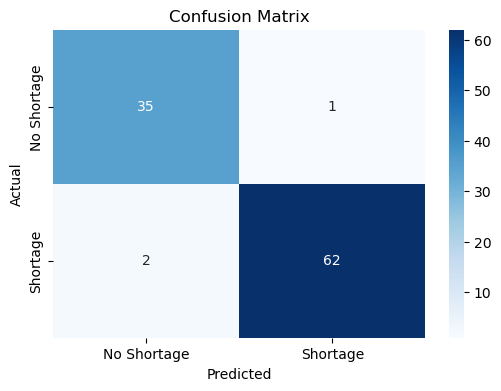

In [47]:
# retrain with these best parameters

# Train the model
best_rf_model.fit(X_train, y_train)

# Make predictions
y_pred = best_rf_model.predict(X_test)

# Evaluate model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=['No Shortage', 'Shortage'], yticklabels=['No Shortage', 'Shortage'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy Score: 0.95
ROC AUC Score: 0.9427083333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       0.95      0.97      0.96        64

    accuracy                           0.95       100
   macro avg       0.95      0.94      0.95       100
weighted avg       0.95      0.95      0.95       100



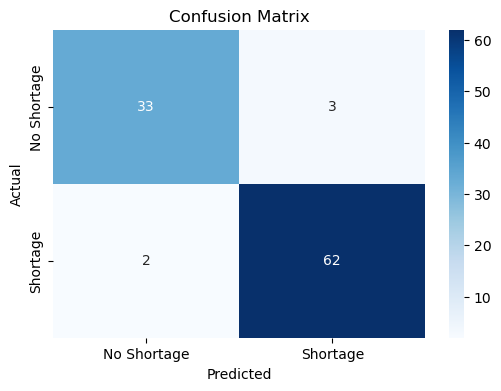

In [48]:
# XGBoost model

from xgboost import XGBClassifier


# Initialize XGBoost classifier with class weight
xgb_model = XGBClassifier(
    scale_pos_weight=weights_dict[1],  # Handle class imbalance
    n_estimators=200,  # Number of trees
    learning_rate=0.05,  # Step size
    max_depth=6,  # Tree depth
    subsample=0.8,  # Subsample ratio
    colsample_bytree=0.8,  # Feature sampling
    objective='binary:logistic',  # Binary classification
    random_state=42,
    eval_metric='auc'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=['No Shortage', 'Shortage'], yticklabels=['No Shortage', 'Shortage'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 0.78125, 'subsample': 0.8}
Best Accuracy: 0.9958606386851823
Accuracy Score: 0.95
ROC AUC Score: 0.9427083333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        36
           1       0.95      0.97      0.96        64

    accuracy                           0.95       100
   macro avg       0.95      0.94      0.95       100
weighted avg       0.95      0.95      0.95       100



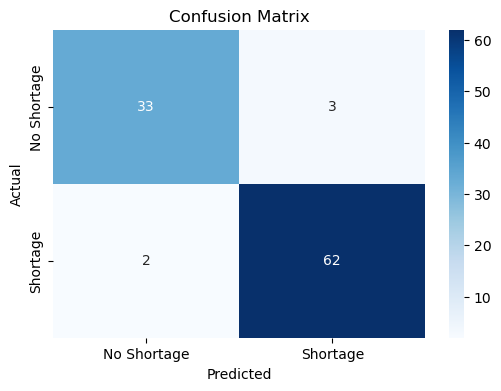

In [57]:
# Hyperparameter Tuning 

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],  # Step size
    'max_depth': [4, 6, 8],  # Tree depth
    'subsample': [0.6, 0.8, 1.0],  # Subsample ratio
    'colsample_bytree': [0.6, 0.8, 1.0],  # Feature sampling
    'scale_pos_weight': [weights_dict[1]],  # Handle class imbalance
}


# Initialize XGBoost classifier 
xgb_model = XGBClassifier(
    objective='binary:logistic',  # Binary classification
    random_state=42,
    eval_metric='auc'
)



# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',  
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all CPU cores
    verbose=2  # Print progress
)

# Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Use the best model for predictions
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

# Evaluate model performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=['No Shortage', 'Shortage'], yticklabels=['No Shortage', 'Shortage'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

C:\Users\salma\AppData\Local\Temp\ipykernel_3584\2154053419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")


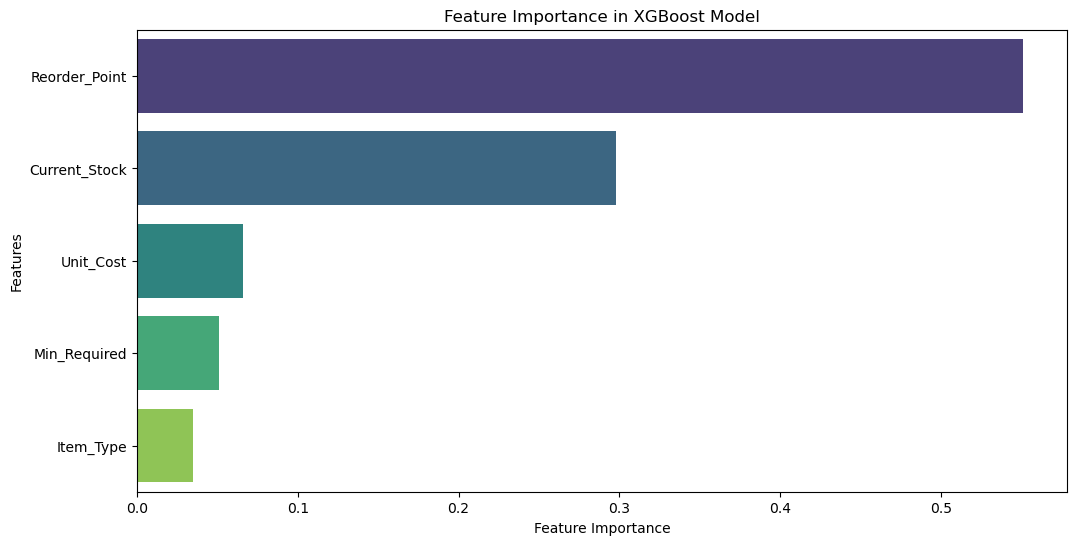

In [49]:
# Plot feature importance
plt.figure(figsize=(12, 6))
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in XGBoost Model")
plt.show()